##### Mole Classifier Kernel
Skin cancer is the most common human malignancy, is primarily diagnosed visually, beginning with an initial clinical screening and followed potentially by dermoscopic analysis, a biopsy and histopathological examination. Automated classification of skin lesions using images is a challenging task owing to the fine-grained variability in the appearance of skin lesions.

The dataset is taken from the ISIC (International Skin Image Collaboration) Archive. It consists of 1800 pictures of benign moles and 1497 pictures of malignant classified moles. The pictures have all been resized to low resolution (224x224x3) RGB. The task of this kernel is to create a model, which can classify a mole visually into benign and malignant.

As the dataset is pretty balanced, the model will be tested on the accuracy score, thus (TP + TN)/(ALL).

It has 2 different classes of skin cancer which are listed below :<br>
**1. Benign <br>**
**2. Malignant <br>**

In this kernel I will try to detect 2 different classes of moles using Convolution Neural Network with keras tensorflow in backend and then analyse the result to see how the model can be useful in practical scenario.<br>

In this kernel I have followed following 14 steps for model building and evaluation which are as follows : <br>
**Step 1 : Importing Essential Libraries**<br>
**Step 2: Loading pictures and making Dictionary of images and labels** <br>
**Step 3: Categorical Labels** <br>
**Step 4: Normalization** <br>
**Step 5: Train and Test Split** <br>
**Step 6: Model Building**<br>
**Step 7: Cross-validating model**<br>
**Step 8: Testing model**<br>
**Step 9: ResNet50** <br>

# Step 1 : importing Essential Libraries

In [ ]:
import os

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
from glob import glob
import seaborn as sns
from PIL import Image
np.random.seed(11) # It's my lucky number
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
import itertools

import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras import backend as K
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.utils import to_categorical
from keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.wrappers import SKLearnClassifier as KerasClassifier
from keras.applications.resnet50 import ResNet50
from keras import backend as K
from tensorflow import stack, float32
from tensorflow import data, io
import tensorflow as tf

In [ ]:
from tensorflow.test import gpu_device_name
from tensorflow.config import list_physical_devices

device_name = gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print('Found GPU at: {}'.format(device_name))

# List all physical GPU devices
print("Physical GPUs:", list_physical_devices('GPU'))

Found GPU at: /device:GPU:0
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Step 2 : Loading pictures and making Dictionary of images and labels
In this step I load in the pictures and turn them into numpy arrays using their RGB values. As the pictures have already been resized to 224x224, there's no need to resize them. As the pictures do not have any labels, these need to be created. Finally, the pictures are added together to a big training set and shuffeled.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

!mkdir /content/dataset
!cp /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/* /content/dataset
!cp /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/* /content/dataset
!cp /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv /content/

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
# =========================
# CONFIGURAÇÕES
# =========================
IMG_SIZE = (224,224,3)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# =========================
# FUNÇÃO DE LEITURA
# =========================
def parse_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(
                            image,
                            [IMG_SIZE[0], IMG_SIZE[1]],
                            method=tf.image.ResizeMethod.BILINEAR,
                            preserve_aspect_ratio=False,
                            antialias=False,
                            name=None
)

    return image, label


# =========================
# CRIAR DATASET
# =========================
def create_dataset(image_paths, labels, training=True):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.map(parse_image, num_parallel_calls=AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [ ]:
folder_dataset = '/content/dataset'

read = lambda imname: np.asarray(Image.open(imname).convert("RGB"))

# Read labels
metadata = pd.read_csv("/content/HAM10000_metadata.csv")[['dx','image_id']]
metadata['paths'] = metadata.image_id.map(lambda x: os.path.join(folder_dataset,x+'.jpg'))


labels = metadata['dx'].unique()
labels.sort()
labels_to_int = dict(zip(labels,range(len(labels))))

metadata['dx'] = metadata['dx'].map(lambda x: labels_to_int[x])

# metadata = pd.concat([metadata, pd.get_dummies(metadata['dx'], dtype=int)],axis=1)

# Load in pictures
train_im_list, test_im_list = train_test_split(metadata, test_size=.3, train_size=.7,shuffle=True)

train_dataset = create_dataset(train_im_list['paths'], train_im_list['dx'], training=True)
val_dataset   = create_dataset(test_im_list['paths'], test_im_list['dx'], training=False)

In [ ]:
display(metadata.head())
# print(train_dataset['label'].head())
# print(train_dataset.shape)
# print(train_dataset.shape)

,dx,image_id,paths,0,1,2,3,4,5,6
0,2,ISIC_0027419,/content/dataset/ISIC_0027419.jpg,0,0,1,0,0,0,0
1,2,ISIC_0025030,/content/dataset/ISIC_0025030.jpg,0,0,1,0,0,0,0
2,2,ISIC_0026769,/content/dataset/ISIC_0026769.jpg,0,0,1,0,0,0,0
3,2,ISIC_0025661,/content/dataset/ISIC_0025661.jpg,0,0,1,0,0,0,0
4,2,ISIC_0031633,/content/dataset/ISIC_0031633.jpg,0,0,1,0,0,0,0


In [ ]:
# # Display first 15 images of moles, and how they are classified
# w=40
# h=30
# fig=plt.figure(figsize=(12, 8))
# columns = 5
# rows = 3

# for i in range(1, columns*rows +1):
#     ax = fig.add_subplot(rows, columns, i)
#     ax.title.set_text(y_train.iloc[i])
#     plt.imshow(x_train[i], interpolation='nearest')
# plt.show()

# Step 5: Model Building
## CNN
I used the Keras Sequential API, where you have just to add one layer at a time, starting from the input.

The first is the convolutional (Conv2D) layer. It is like a set of learnable filters. I choosed to set 64 filters for the two firsts conv2D layers. Each filter transforms a part of the image (defined by the kernel size) using the kernel filter. The kernel filter matrix is applied on the whole image. Filters can be seen as a transformation of the image.

The CNN can isolate features that are useful everywhere from these transformed images (feature maps).

The second important layer in CNN is the pooling (MaxPool2D) layer. This layer simply acts as a downsampling filter. It looks at the 2 neighboring pixels and picks the maximal value. These are used to reduce computational cost, and to some extent also reduce overfitting. We have to choose the pooling size (i.e the area size pooled each time) more the pooling dimension is high, more the downsampling is important.

Combining convolutional and pooling layers, CNN are able to combine local features and learn more global features of the image.

Dropout is a regularization method, where a proportion of nodes in the layer are randomly ignored (setting their wieghts to zero) for each training sample. This drops randomly a propotion of the network and forces the network to learn features in a distributed way. This technique also improves generalization and reduces the overfitting.

'relu' is the rectifier (activation function max(0,x). The rectifier activation function is used to add non linearity to the network.

The Flatten layer is use to convert the final feature maps into a one single 1D vector. This flattening step is needed so that you can make use of fully connected layers after some convolutional/maxpool layers. It combines all the found local features of the previous convolutional layers.

In the end i used the features in one fully-connected (Dense) layer which is just artificial an neural networks (ANN) classifier.

In [ ]:
# See learning curve and validation curve

def build(input_shape= (224,224,3), lr = 1e-3, num_classes= 7,
          init= 'normal', activ= 'relu', optim= 'adam'):
    model = Sequential()
    model.add(Conv2D(64, kernel_size=(3, 3),padding = 'Same',input_shape=input_shape,
                     activation= activ, kernel_initializer='glorot_uniform'))
    model.add(MaxPool2D(pool_size = (2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, kernel_size=(3, 3),padding = 'Same',
                     activation =activ, kernel_initializer = 'glorot_uniform'))
    model.add(MaxPool2D(pool_size = (2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer=init))
    model.add(Dense(num_classes, activation='softmax'))
    model.summary()

    if optim == 'rmsprop':
        optimizer = RMSprop(learning_rate=lr)

    else:
        optimizer = Adam(learning_rate=lr)

    model.compile(optimizer = optimizer ,loss = "binary_crossentropy", metrics=["accuracy"])
    return model

In [ ]:
# Set a learning rate annealer
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            mode="max",
                                            patience=5,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=1e-7)

In [ ]:
input_shape = (450,600,3)
lr = 1e-3
init = 'normal'
activ = 'relu'
optim = 'adam'
epochs = 50

model = build(lr=lr, init= init, activ= activ, optim= optim, input_shape= input_shape)

history = model.fit(train_dataset, validation_data=val_dataset, validation_split=0.2,
                    epochs= epochs, batch_size= BATCH_SIZE, verbose=1,
                    callbacks=[learning_rate_reduction]
                   )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 450, 600, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 225, 300, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 225, 300, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 225, 300, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 112, 150, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 150, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1075200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │   137,625,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,665,351 (525.15 MB)

 Trainable params: 137,665,351 (525.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 139s 534ms/step - accuracy: 0.6625 - loss: 0.4918 - val_accuracy: 0.6602 - val_loss: 0.4373 - learning_rate: 0.0010
Epoch 2/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 100s 454ms/step - accuracy: 0.6763 - loss: 0.2172 - val_accuracy: 0.6552 - val_loss: 0.2576 - learning_rate: 0.0010
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 105s 477ms/step - accuracy: 0.6927 - loss: 0.2010 - val_accuracy: 0.6792 - val_loss: 0.2888 - learning_rate: 0.0010
Epoch 4/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 105s 477ms/step - accuracy: 0.7074 - loss: 0.1891 - val_accuracy: 0.6869 - val_loss: 0.2279 - learning_rate: 0.0010
Epoch 5/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 99s 449ms/step - accuracy: 0.7338 - loss: 0.1742 - val_accuracy: 0.6932 - val_loss: 0.2107 - learning_rate: 0.0010
Epoch 6/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 141s 446ms/step - accuracy: 0.7738 - loss: 0.1532 - val_accuracy: 0.6925 - val_loss: 0.2294 - learning_rate: 0.0010
Epoch 7/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 99s 448ms/step - accuracy

KeyError: 'acc'

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


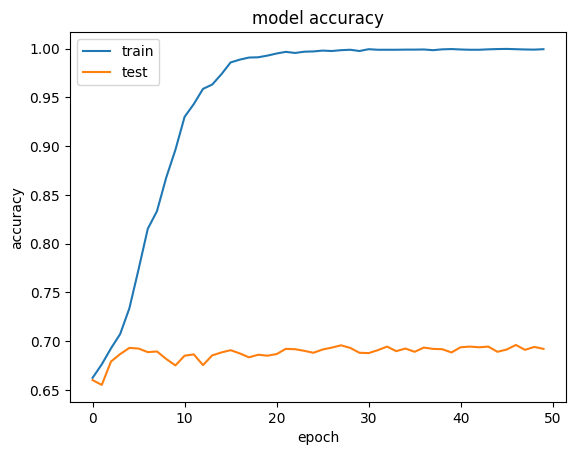

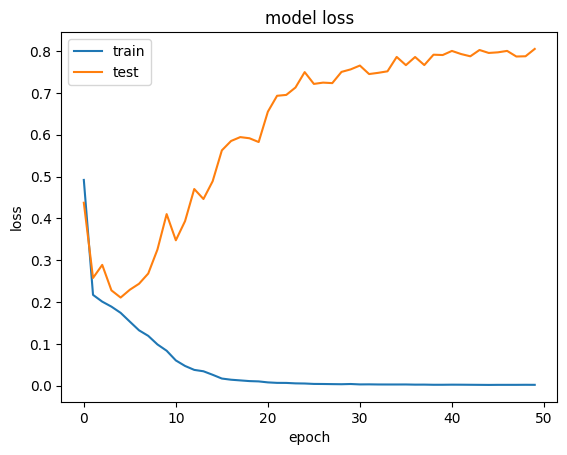

In [ ]:
# list all data in history
print(history.history.keys())

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
clear_session()
del model
del history

# Step 6: ResNet50
The CNN above is not a very sophisticated model, thus the resnet50, is also tried

In [ ]:
from tensorflow.keras import layers, models

# Parâmetros
NUM_CLASSES = 7

# Base pré-treinada
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE
)

# Congela toda a ResNet50
base_model.trainable = False

# Monta o novo modelo
inputs = tf.keras.Input(shape=IMG_SIZE)

# Pré-processamento esperado pela ResNet50
x = tf.keras.applications.resnet50.preprocess_input(inputs)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

# Compilação
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    262,272 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 7)         │        903 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
lr = 1e-5
epochs = 50

history = model.fit(train_dataset, validation_data=val_dataset, validation_split=0.2,
                    epochs= epochs, batch_size= BATCH_SIZE, verbose=1,
                    callbacks=[learning_rate_reduction]
)


Epoch 1/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 102s 391ms/step - accuracy: 0.6589 - loss: 1.2260 - val_accuracy: 0.6636 - val_loss: 1.1571 - learning_rate: 0.0010
Epoch 2/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 55s 248ms/step - accuracy: 0.6720 - loss: 1.1672 - val_accuracy: 0.6636 - val_loss: 1.1464 - learning_rate: 0.0010
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 83s 252ms/step - accuracy: 0.6720 - loss: 1.1631 - val_accuracy: 0.6636 - val_loss: 1.1448 - learning_rate: 0.0010
Epoch 4/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 80s 245ms/step - accuracy: 0.6720 - loss: 1.1558 - val_accuracy: 0.6636 - val_loss: 1.1466 - learning_rate: 0.0010
Epoch 5/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 77s 222ms/step - accuracy: 0.6720 - loss: 1.1497 - val_accuracy: 0.6636 - val_loss: 1.1393 - learning_rate: 0.0010
Epoch 6/50
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6779 - loss: 1.1358
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
220/220 ━━━━━━━━━━━━━━━━━━━━ 87s 245ms/step - accuracy: 0.67

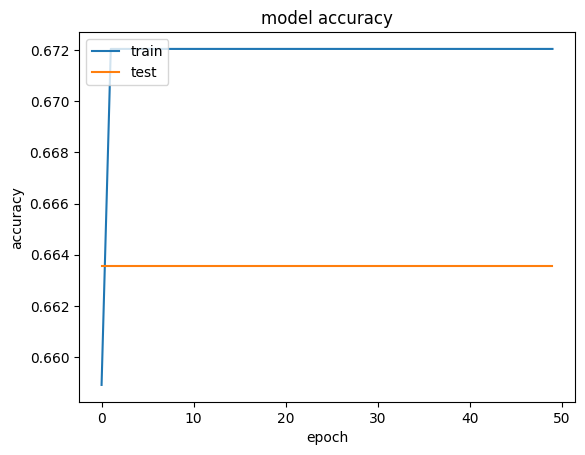

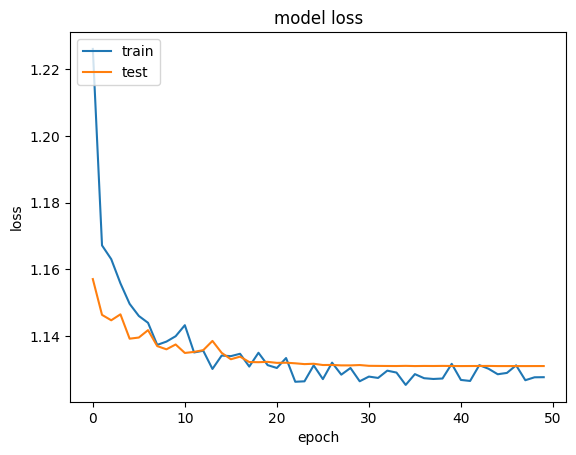

In [ ]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
# Testing model on test data to evaluate
y_pred = model.predict(test)
print(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1)))

# save model
# serialize model to JSON
resnet50_json = model.to_json()

with open("resnet50.json", "w") as json_file:
    json_file.write(resnet50_json)

# serialize weights to HDF5
model.save_weights("resnet50.h5")
print("Saved model to disk")